In [1]:
using LinearAlgebra
using Printf
using Plots

gr()

a_default = 1.0
b_default = 3.0

penalty(g_val) = max(0.0, g_val)^2

function objective_Q(f, g, x, r)
    return f(x) + r * penalty(g(x))
end

function numeric_gradient(phi, x; h=1e-6)
    grad = zeros(length(x))
    for i in eachindex(x)
        e = zeros(length(x))
        e[i] = 1.0
        grad[i] = (phi(x + h * e) - phi(x - h * e)) / (2h)
    end
    return grad
end

function gradient_descent(phi, x0; max_iter=5000, tol=1e-8, step0=1.0)
    x = copy(x0)
    history = [copy(x)]

    for _ in 1:max_iter
        grad = numeric_gradient(phi, x)
        ng = norm(grad)
        if ng < tol
            break
        end

        α = step0
        fx = phi(x)
        accepted = false

        for _ in 1:40
            x_new = x - α * grad
            if phi(x_new) <= fx - 1e-4 * α * ng^2
                x = x_new
                push!(history, copy(x))
                accepted = true
                break
            end
            α *= 0.5
        end

        if !accepted
            break
        end
    end

    return x, history
end

function penalty_outer_method(f, g, x0, r_values)
    x = copy(x0)
    solutions = Vector{typeof(copy(x0))}()
    trajectories = Vector{Vector{typeof(copy(x0))}}()

    for r in r_values
        phi(z) = objective_Q(f, g, z, r)
        x, hist = gradient_descent(phi, x)
        push!(solutions, copy(x))
        push!(trajectories, hist)
    end

    return solutions, trajectories
end

penalty_outer_method (generic function with 1 method)

R1 -> R2: релаксационная последовательность
--------------------------------------------------------------
r =     1.0 | x(r) =   2.000000 | f(x) =   1.000000 | g(x) =   1.000000 | Q =   2.000000
r =    10.0 | x(r) =   1.181818 | f(x) =   3.305785 | g(x) =   0.181818 | Q =   3.636364
r =   100.0 | x(r) =   1.019802 | f(x) =   3.921184 | g(x) =   0.019802 | Q =   3.960396
r =   200.0 | x(r) =   1.009950 | f(x) =   3.960298 | g(x) =   0.009950 | Q =   3.980100
r =   500.0 | x(r) =   1.003992 | f(x) =   3.984048 | g(x) =   0.003992 | Q =   3.992016
r =  1000.0 | x(r) =   1.001998 | f(x) =   3.992012 | g(x) =   0.001998 | Q =   3.996004
Итог (самое большое r): x* ≈ 1.001998, f(x*) = 3.992012, g(x*) = 0.001998, Q = 3.996004



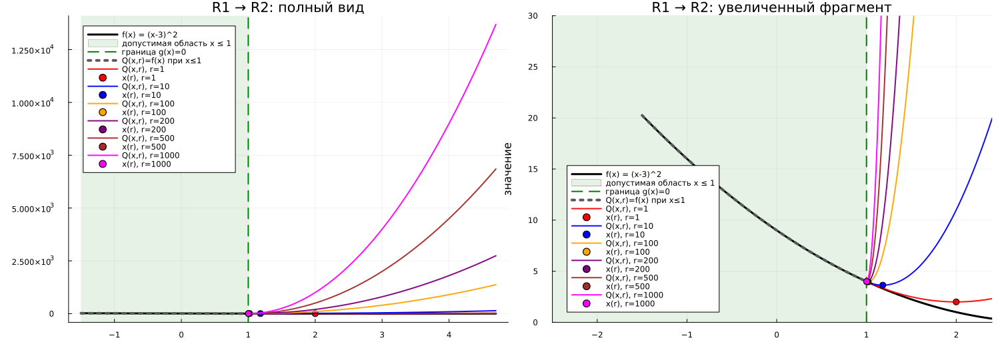

In [2]:
r_values_1d = [1.0, 10.0, 100.0, 200.0, 500.0, 1000.0]

f1(v) = (v[1] - 3.0)^2
g1(v) = v[1] - 1.0   # ограничение x <= 1

x0_1d = [3.5]         # старт во внешней (недопустимой) области
sol_1d, traj_1d = penalty_outer_method(f1, g1, x0_1d, r_values_1d)

println("R1 -> R2: релаксационная последовательность")
println("--------------------------------------------------------------")
for (r, x) in zip(r_values_1d, sol_1d)
    @printf("r = %7.1f | x(r) = %10.6f | f(x) = %10.6f | g(x) = %10.6f | Q = %10.6f\n",
            r, x[1], f1(x), g1(x), objective_Q(f1, g1, x, r))
end

x_best_1d = sol_1d[end]
r_best_1d = r_values_1d[end]
@printf("Итог (самое большое r): x* ≈ %.6f, f(x*) = %.6f, g(x*) = %.6f, Q = %.6f\n\n",
        x_best_1d[1], f1(x_best_1d), g1(x_best_1d), objective_Q(f1, g1, x_best_1d, r_best_1d))

x_all_1d = vcat([x0_1d[1], 1.0, 3.0], [p[1] for p in sol_1d])
xmin1 = minimum(x_all_1d) - 2.5
xmax1 = maximum(x_all_1d) + 1.2

xgrid = range(xmin1, xmax1, length=700)
x_feas = range(xmin1, 1.0, length=420)
x_viol = range(1.0, xmax1, length=320)
y_f = [(x - 3.0)^2 for x in xgrid]

palette = [:red, :blue, :orange, :purple, :brown, :magenta]

p_curve_full = plot(xgrid, y_f,
    lw=3,
    color=:black,
    label="f(x) = (x-3)^2",
    xlabel="x",
    ylabel="значение",
    title="R1 → R2: полный вид")
vspan!(p_curve_full, [xmin1, 1.0], alpha=0.10, color=:green, label="допустимая область x ≤ 1")
vline!(p_curve_full, [1.0], lw=2, ls=:dash, color=:green, label="граница g(x)=0")

zoom_left = min(-2.5, minimum([p[1] for p in sol_1d]) - 0.6)
zoom_right = max(2.2, maximum([p[1] for p in sol_1d]) + 0.4)

x_zoom = range(zoom_left, zoom_right, length=320)
y_zoom_candidates = [(x - 3.0)^2 for x in x_zoom]
for r in r_values_1d
    append!(y_zoom_candidates, [objective_Q(f1, g1, [x], r) for x in x_zoom])
end

y_zoom_raw = maximum(y_zoom_candidates) * 1.05
y_zoom_max = min(30.0, max(12.0, y_zoom_raw))

yt_step = y_zoom_max <= 20 ? 2.0 : 5.0
p_curve_zoom = plot(xgrid, y_f,
    lw=3,
    color=:black,
    label="f(x) = (x-3)^2",
    xlabel="x",
    ylabel="значение",
    xlims=(zoom_left, zoom_right),
    ylims=(0.0, y_zoom_max),
    yticks=collect(0.0:yt_step:y_zoom_max),
    title="R1 → R2: увеличенный фрагмент")
vspan!(p_curve_zoom, [zoom_left, 1.0], alpha=0.10, color=:green, label="допустимая область x ≤ 1")
vline!(p_curve_zoom, [1.0], lw=2, ls=:dash, color=:green, label="граница g(x)=0")

plot!(p_curve_full, x_feas, [(x - 3.0)^2 for x in x_feas],
    lw=4, color=:gray35, ls=:dot, label="Q(x,r)=f(x) при x≤1")
plot!(p_curve_zoom, x_feas, [(x - 3.0)^2 for x in x_feas],
    lw=4, color=:gray35, ls=:dot, label="Q(x,r)=f(x) при x≤1")

for (k, r) in enumerate(r_values_1d)
    col = palette[mod1(k, length(palette))]

    y_q_viol = [objective_Q(f1, g1, [x], r) for x in x_viol]
    plot!(p_curve_full, x_viol, y_q_viol, lw=2, color=col, alpha=0.95, label="Q(x,r), r=$(Int(r))")
    plot!(p_curve_zoom, x_viol, y_q_viol, lw=2, color=col, alpha=0.95, label="Q(x,r), r=$(Int(r))")

    xr = sol_1d[k][1]
    yr = objective_Q(f1, g1, [xr], r)

    scatter!(p_curve_full, [xr], [yr], color=col, marker=:circle, markersize=5, label="x(r), r=$(Int(r))")
    scatter!(p_curve_zoom, [xr], [yr], color=col, marker=:circle, markersize=5, label="x(r), r=$(Int(r))")
end

plot!(p_curve_zoom, legend=:bottomleft)

plot(p_curve_full, p_curve_zoom, layout=(1,2), size=(1500, 520))


R2 -> R3: релаксационная последовательность
--------------------------------------------------------------------------------
r =     1.0 | x(r) = [ 1.121953, -1.356411] | f =   2.828346 | g =   1.428566 | Q =   4.869145
r =    10.0 | x(r) = [ 0.700379, -1.167339] | f =   7.833630 | g =   0.389591 | Q =   9.351445
r =   100.0 | x(r) = [ 0.572176, -1.058661] | f =  10.985543 | g =   0.057546 | Q =  11.316700
r =   200.0 | x(r) = [ 0.561969, -1.048037] | f =  11.310560 | g =   0.029796 | Q =  11.488120
r =   500.0 | x(r) = [ 0.555539, -1.041159] | f =  11.522780 | g =   0.012188 | Q =  11.597056
Итог (самое большое r): x* ≈ [0.555539, -1.041159], f(x*) = 11.522780, g(x*) = 0.012188, Q = 11.597056



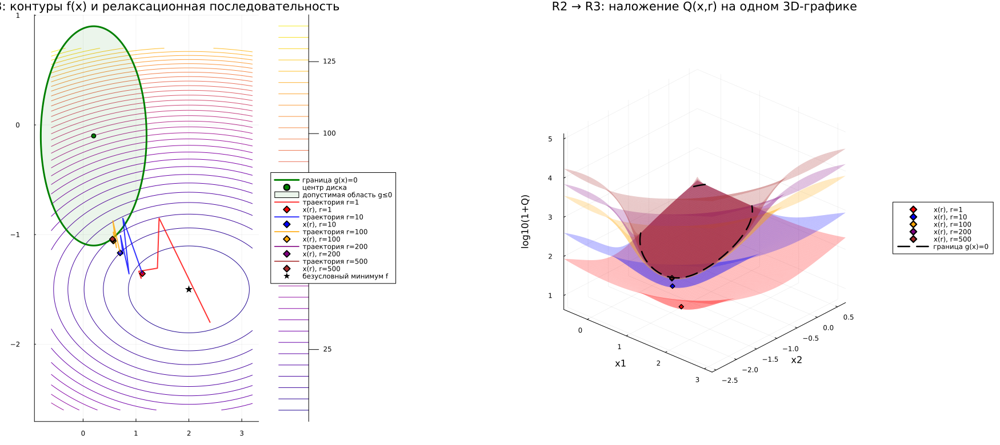

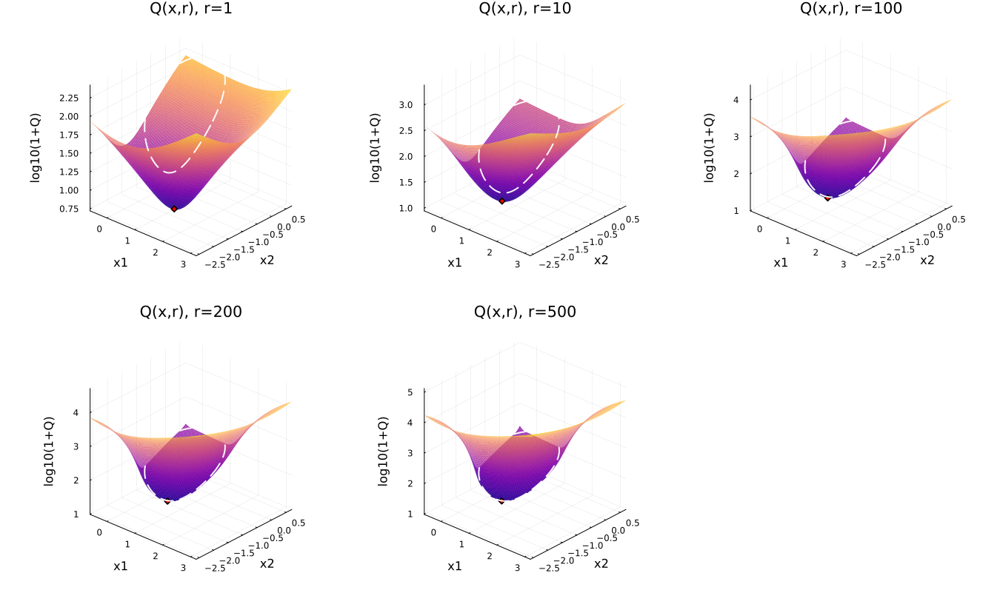

In [5]:
α = 3      # коэффициент по x1
β = 25      # коэффициент по x2
c1, c2 = 2.0, -1.5 # минимум f без ограничений
xc, yc = 0.2, -0.1 # центр допустимого диска
R = 1.0            # радиус диска

f2(v) = α * (v[1] - c1)^2 + β * (v[2] - c2)^2
g2(v) = (v[1] - xc)^2 + (v[2] - yc)^2 - R^2

r_values_2d = [1.0, 10.0, 100.0, 200.0, 500.0]
x0_2d = [2.4, -1.8]    # внешняя точка

sol_2d, traj_2d = penalty_outer_method(f2, g2, x0_2d, r_values_2d)

println("\nR2 -> R3: релаксационная последовательность")
println("--------------------------------------------------------------------------------")
for (r, x) in zip(r_values_2d, sol_2d)
    @printf("r = %7.1f | x(r) = [%9.6f, %9.6f] | f = %10.6f | g = %10.6f | Q = %10.6f\n",
            r, x[1], x[2], f2(x), g2(x), objective_Q(f2, g2, x, r))
end

x_best_2d = sol_2d[end]
r_best_2d = r_values_2d[end]
@printf("Итог (самое большое r): x* ≈ [%.6f, %.6f], f(x*) = %.6f, g(x*) = %.6f, Q = %.6f\n\n",
        x_best_2d[1], x_best_2d[2], f2(x_best_2d), g2(x_best_2d), objective_Q(f2, g2, x_best_2d, r_best_2d))

all_hist_points = reduce(vcat, traj_2d)
traj_x = [p[1] for p in all_hist_points]
traj_y = [p[2] for p in all_hist_points]

x_ref = vcat(traj_x, [xc, c1, x0_2d[1]])
y_ref = vcat(traj_y, [yc, c2, x0_2d[2]])

xpad = max(0.8, 0.2 * (maximum(x_ref) - minimum(x_ref) + 1e-9))
ypad = max(0.8, 0.2 * (maximum(y_ref) - minimum(y_ref) + 1e-9))

xmin, xmax = minimum(x_ref) - xpad, maximum(x_ref) + xpad
ymin, ymax = minimum(y_ref) - ypad, maximum(y_ref) + ypad

xg = range(xmin, xmax, length=250)
yg = range(ymin, ymax, length=250)
Zf = [f2([x, y]) for y in yg, x in xg]

p_contour = contour(xg, yg, Zf,
    levels=35,
    c=:plasma,
    xlabel="x1",
    ylabel="x2",
    title="R2 → R3: контуры f(x) и релаксационная последовательность",
    legend=:outerright)

θ = range(0, 2pi, length=300)
xcirc = [xc + R * cos(t) for t in θ]
ycirc = [yc + R * sin(t) for t in θ]

plot!(p_contour, xcirc, ycirc, color=:green, lw=3, label="граница g(x)=0")
scatter!(p_contour, [xc], [yc], color=:green, markersize=4, label="центр диска")

shape = Shape(xcirc, ycirc)
plot!(p_contour, shape, c=:green, fillalpha=0.08, linealpha=0.0, label="допустимая область g≤0")

colors = [:red, :blue, :orange, :purple, :brown, :magenta]

for (k, r) in enumerate(r_values_2d)
    hist = traj_2d[k]
    xs = [p[1] for p in hist]
    ys = [p[2] for p in hist]
    col = colors[mod1(k, length(colors))]

    plot!(p_contour, xs, ys, lw=2, color=col, alpha=0.8, label="траектория r=$(Int(r))")
    scatter!(p_contour, [sol_2d[k][1]], [sol_2d[k][2]], color=col, marker=:diamond, markersize=5, label="x(r), r=$(Int(r))")
end

scatter!(p_contour, [c1], [c2], marker=:star5, color=:black, markersize=7, label="безусловный минимум f")

xmin3, xmax3 = xmin, xmax
ymin3, ymax3 = ymin, ymax

xg3 = range(xmin3, xmax3, length=90)
yg3 = range(ymin3, ymax3, length=90)

q_to_vis(z) = log10(1.0 + z)

p_overlay = plot(
    xlabel="x1",
    ylabel="x2",
    zlabel="log10(1+Q)",
    xlims=(xmin3, xmax3),
    ylims=(ymin3, ymax3),
    camera=(42, 28),
    title="R2 → R3: наложение Q(x,r) на одном 3D-графике",
    legend=:outerright)

for (k, r) in enumerate(r_values_2d)
    col = colors[mod1(k, length(colors))]

    Zq = [objective_Q(f2, g2, [x, y], r) for y in yg3, x in xg3]
    Zvis = q_to_vis.(Zq)

    surface!(p_overlay, xg3, yg3, Zvis,
        alpha=0.26,
        color=col,
        colorbar=false,
        label="Q(x,r), r=$(Int(r))")

    xr = sol_2d[k]
    zr = q_to_vis(objective_Q(f2, g2, xr, r))
    scatter!(p_overlay, [xr[1]], [xr[2]], [zr],
        color=col, marker=:diamond, markersize=4, label="x(r), r=$(Int(r))")
end

zcirc_base = [q_to_vis(objective_Q(f2, g2, [xx, yy], r_values_2d[end])) for (xx, yy) in zip(xcirc, ycirc)]
plot!(p_overlay, xcirc, ycirc, zcirc_base, lw=2.5, ls=:dash, color=:black, label="граница g(x)=0")

surface_plots = Any[]
for (k, r) in enumerate(r_values_2d)
    col = colors[mod1(k, length(colors))]

    Zq = [objective_Q(f2, g2, [x, y], r) for y in yg3, x in xg3]
    Zvis = q_to_vis.(Zq)

    p_r = surface(xg3, yg3, Zvis,
        alpha=0.85,
        c=:plasma,
        colorbar=false,
        xlabel="x1",
        ylabel="x2",
        zlabel="log10(1+Q)",
        xlims=(xmin3, xmax3),
        ylims=(ymin3, ymax3),
        camera=(42, 28),
        title="Q(x,r), r=$(Int(r))",
        legend=false)

    xr = sol_2d[k]
    zr = q_to_vis(objective_Q(f2, g2, xr, r))
    scatter!(p_r, [xr[1]], [xr[2]], [zr],
        color=:red, marker=:diamond, markersize=4, label="")

    zcirc_r = [q_to_vis(objective_Q(f2, g2, [xx, yy], r)) for (xx, yy) in zip(xcirc, ycirc)]
    plot!(p_r, xcirc, ycirc, zcirc_r, lw=2, ls=:dash, color=:white, alpha=0.95, label="")

    push!(surface_plots, p_r)
end

p_surfaces = plot(surface_plots..., layout=(2,3), size=(1350, 820))

display(plot(p_contour, p_overlay, layout=(1,2), size=(1750, 780)))
display(p_surfaces)